In [30]:
import pandas as pd

url = "https://archive.ics.uci.edu/ml/machine-learning-databases/mfeat/mfeat-fou"

df = pd.read_csv(url, sep=r"\s+", header=None)
print("Shape of the dataset:", df.shape)

Shape of the dataset: (2000, 76)


In [37]:
print("Total missing values in dataset:", df.isnull().sum().sum())

print("\nMissing values per column (first 10 columns):")
print(df.isnull().sum().head(10))

print("\nFirst 5 rows of the dataset:")
print(df.head().to_string(index=False))

Total missing values in dataset: 0

Missing values per column (first 10 columns):
0    0
1    0
2    0
3    0
4    0
5    0
6    0
7    0
8    0
9    0
dtype: int64

First 5 rows of the dataset:
      0        1        2        3        4        5        6        7        8        9        10       11       12       13       14       15       16       17       18       19       20       21       22       23       24       25       26       27       28       29       30       31       32       33       34       35       36       37       38       39       40       41       42       43       44       45       46       47       48       49       50       51       52       53       54       55       56       57       58       59       60       61       62       63       64       65       66       67       68       69       70       71       72       73       74       75
0.065882 0.197312 0.103826 0.270362 0.616078 0.035856 0.424572 0.089701 0.367773 0.037065 0.075942 0.263906 0.077903 0.37

In [38]:
from sklearn.preprocessing import StandardScaler
import numpy as np

scaler = StandardScaler()

X_scaled = scaler.fit_transform(df)
print("Scaled data shape:", X_scaled.shape)

means = np.mean(X_scaled, axis=0)
stds = np.std(X_scaled, axis=0)

print("\nMeans of the first 5 features after scaling:")
print(means[:5])
print("\nStandard deviations of the first 5 features after scaling:")
print(stds[:5])

Scaled data shape: (2000, 76)

Means of the first 5 features after scaling:
[-3.69482223e-16  5.68434189e-17 -2.48689958e-16  2.27373675e-16
 -9.23705556e-17]

Standard deviations of the first 5 features after scaling:
[1. 1. 1. 1. 1.]


In [39]:
# verifying entire distributions, not samples.

print("Mean statistics across all features:")
print("Min mean:", np.min(means))
print("Max mean:", np.max(means))

print("\nStd statistics across all features:")
print("Min std:", np.min(stds))
print("Max std:", np.max(stds))

Mean statistics across all features:
Min mean: -3.694822225952521e-16
Max mean: 3.836930773104541e-16

Std statistics across all features:
Min std: 0.9999999999999998
Max std: 1.0000000000000002


> nearest-neighbor distances behave in 76D space.

> In high-dimensional space, distances tend to concentrate, meaning nearest and farthest neighbors become similar.

In [40]:
from sklearn.neighbors import NearestNeighbors

k = 10

nn = NearestNeighbors(n_neighbors=k)
nn.fit(X_scaled)

distances, indices = nn.kneighbors(X_scaled)

print("Distance matrix shape:", distances.shape)
print("Indices matrix shape:", indices.shape)

print("\nDistances to the 10 nearest neighbors for the first 5 samples:")
print(distances[:5])

Distance matrix shape: (2000, 10)
Indices matrix shape: (2000, 10)

Distances to the 10 nearest neighbors for the first 5 samples:
[[0.         3.90915208 4.4238854  4.50976414 4.51349611 5.0078607
  5.09845663 5.22848728 5.26090882 5.27769987]
 [0.         3.6639822  4.37975302 4.42049259 4.62467566 4.78760124
  4.98535303 5.0450245  5.11394889 5.24967069]
 [0.         4.83550387 4.93193025 4.99040249 5.02286634 5.39395628
  5.4913696  5.56911814 5.74104795 5.81208753]
 [0.         3.13850226 4.22961001 4.53025815 4.60433791 4.61754648
  4.67897032 4.74843194 4.89776905 4.92250168]
 [0.         3.97405066 4.08412484 4.17929391 4.54798744 4.69941085
  4.86120656 4.86956942 5.0258447  5.23256933]]


In [41]:
# DBSCAN ε is typically chosen at the elbow of the sorted k-distance curve.

k = 10

k_distances = distances[:, k-1]

print("k-distance vector shape:", k_distances.shape)

print("\nFirst 10 k-distances:")
print(k_distances[:10])

k-distance vector shape: (2000,)

First 10 k-distances:
[5.27769987 5.24967069 5.81208753 4.92250168 5.23256933 5.64617738
 5.96288638 6.83647022 6.10653315 5.46489793]


Smallest k-distance:  3.414358278712282
Largest k-distance:  15.582411158472109


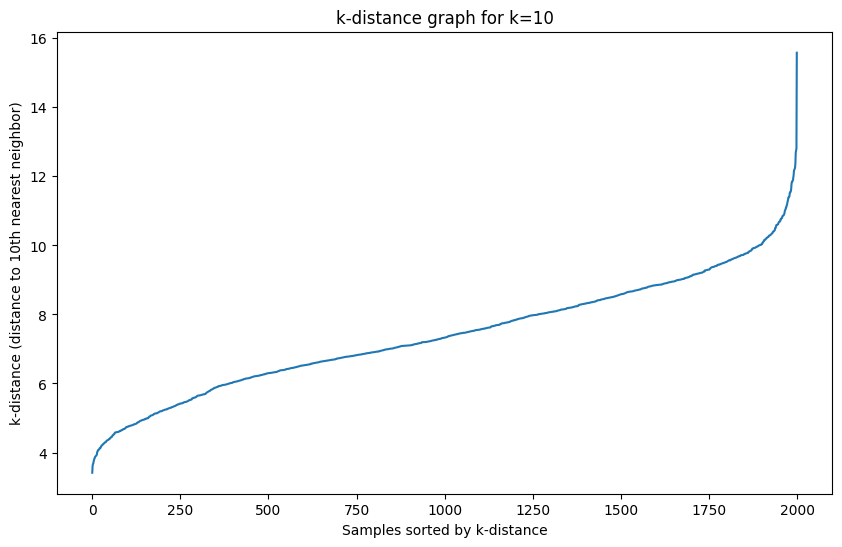

In [42]:
import matplotlib.pyplot as plt

k_distances_sorted = np.sort(k_distances)

print("Smallest k-distance: ", k_distances_sorted[0])
print("Largest k-distance: ", k_distances_sorted[-1])

plt.figure(figsize=(10, 6))
plt.plot(k_distances_sorted)

plt.title("k-distance graph for k=10")
plt.xlabel("Samples sorted by k-distance")
plt.ylabel("k-distance (distance to 10th nearest neighbor)")

plt.show()

In [45]:
# DBSCAN with estimated parameters

from sklearn.cluster import DBSCAN
import numpy as np

eps = 10.5
min_pts = 10

db = DBSCAN(eps=eps, min_samples=min_pts)

labels = db.fit_predict(X_scaled)

# cluster statistics
n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
n_noise = np.sum(labels == -1)

print("Epsilon:", eps)
print("MinPts:", min_pts)

print("\nNumber of clusters:", n_clusters)
print("Number of noise points:", n_noise)

# cluster size distribution
unique, counts = np.unique(labels, return_counts=True)

print("\nCluster distribution (label : size):")
for u, c in zip(unique, counts):
    print(u, ":", c)

Epsilon: 10.5
MinPts: 10

Number of clusters: 1
Number of noise points: 16

Cluster distribution (label : size):
-1 : 16
0 : 1984


In [46]:
eps = 9.5
min_pts = 10

db = DBSCAN(eps=eps, min_samples=min_pts)

labels = db.fit_predict(X_scaled)

# cluster statistics
n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
n_noise = np.sum(labels == -1)

print("Epsilon:", eps)
print("MinPts:", min_pts)

print("\nNumber of clusters:", n_clusters)
print("Number of noise points:", n_noise)

# cluster distribution
unique, counts = np.unique(labels, return_counts=True)

print("\nCluster distribution:")
for u, c in zip(unique, counts):
    print(u, ":", c)

Epsilon: 9.5
MinPts: 10

Number of clusters: 1
Number of noise points: 60

Cluster distribution:
-1 : 60
0 : 1940


In [47]:
eps = 8.5
min_pts = 10

db = DBSCAN(eps=eps, min_samples=min_pts)

labels = db.fit_predict(X_scaled)

# cluster statistics
n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
n_noise = np.sum(labels == -1)

print("Epsilon:", eps)
print("MinPts:", min_pts)

print("\nNumber of clusters:", n_clusters)
print("Number of noise points:", n_noise)

# cluster distribution
unique, counts = np.unique(labels, return_counts=True)

print("\nCluster distribution:")
for u, c in zip(unique, counts):
    print(u, ":", c)

Epsilon: 8.5
MinPts: 10

Number of clusters: 1
Number of noise points: 223

Cluster distribution:
-1 : 223
0 : 1777


In [48]:
# PCA reduction

from sklearn.decomposition import PCA

pca = PCA(n_components=2)

X_pca = pca.fit_transform(X_scaled)

print("PCA transformed shape:", X_pca.shape)

print("\nExplained variance ratio:")
print(pca.explained_variance_ratio_)

print("\nTotal variance explained:")
print(pca.explained_variance_ratio_.sum())

PCA transformed shape: (2000, 2)

Explained variance ratio:
[0.15620337 0.06826853]

Total variance explained:
0.22447189280449592


Variance retained by first components:
2 components: 0.22447189280449592
5 components: 0.3566015445579883
10 components: 0.49156918609097733
20 components: 0.6665061920711096
30 components: 0.775432002249811
40 components: 0.8556885634103671
50 components: 0.9164303201954276


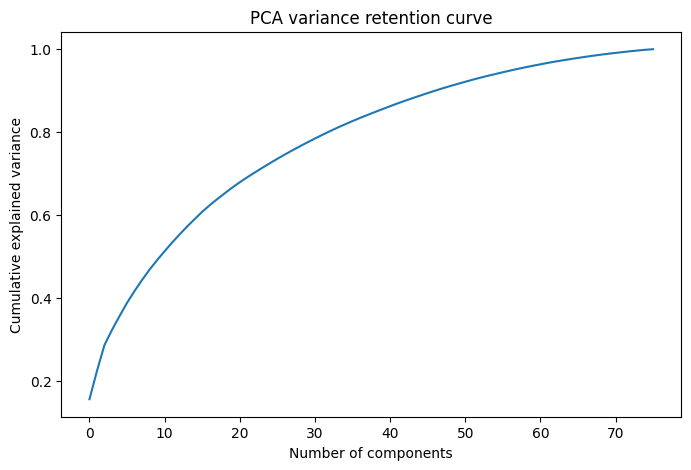

In [49]:
pca_full = PCA()
pca_full.fit(X_scaled)

cumulative_variance = np.cumsum(pca_full.explained_variance_ratio_)

print("Variance retained by first components:")
for i in [2,5,10,20,30,40,50]:
    print(f"{i} components:", cumulative_variance[i-1])

plt.figure(figsize=(8,5))
plt.plot(cumulative_variance)

plt.xlabel("Number of components")
plt.ylabel("Cumulative explained variance")
plt.title("PCA variance retention curve")

plt.show()

The curve shows a slow decay, meaning information is spread across many dimensions.

In [50]:
# Reduce dataset to 30 principal components

from sklearn.decomposition import PCA

pca_30 = PCA(n_components=30)

X_pca30 = pca_30.fit_transform(X_scaled)

print("Reduced dataset shape:", X_pca30.shape)

print("\nVariance retained with 30 components:")
print(pca_30.explained_variance_ratio_.sum())

Reduced dataset shape: (2000, 30)

Variance retained with 30 components:
0.7754320022498109


In [51]:
k = 10

nn = NearestNeighbors(n_neighbors=k)
nn.fit(X_pca30)

distances_pca, indices_pca = nn.kneighbors(X_pca30)

k_distances_pca = distances_pca[:, k-1]

print("k-distance vector shape:", k_distances_pca.shape)

print("\nFirst 10 k-distances:")
print(k_distances_pca[:10])

k-distance vector shape: (2000,)

First 10 k-distances:
[4.19328459 4.17956442 4.39719786 3.56608297 3.98585219 4.23580715
 4.50946577 5.05109093 4.62993976 4.16860171]


Smallest k-distance: 2.515817975396347
Largest k-distance: 12.9106742522267


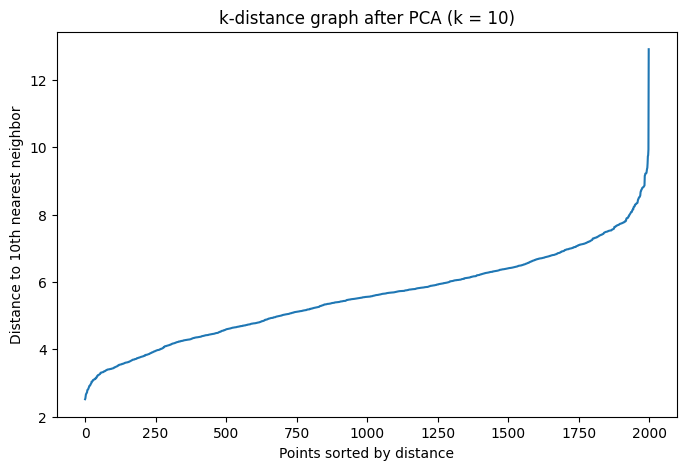

In [52]:
k_dist_sorted = np.sort(k_distances_pca)

print("Smallest k-distance:", k_dist_sorted[0])
print("Largest k-distance:", k_dist_sorted[-1])

plt.figure(figsize=(8,5))
plt.plot(k_dist_sorted)

plt.title("k-distance graph after PCA (k = 10)")
plt.xlabel("Points sorted by distance")
plt.ylabel("Distance to 10th nearest neighbor")

plt.show()

In [53]:
eps = 7.8
min_pts = 10

db = DBSCAN(eps=eps, min_samples=min_pts)

labels_pca = db.fit_predict(X_pca30)

# cluster statistics
n_clusters = len(set(labels_pca)) - (1 if -1 in labels_pca else 0)
n_noise = np.sum(labels_pca == -1)

print("Epsilon:", eps)
print("MinPts:", min_pts)

print("\nNumber of clusters:", n_clusters)
print("Number of noise points:", n_noise)

# cluster distribution
unique, counts = np.unique(labels_pca, return_counts=True)

print("\nCluster distribution:")
for u, c in zip(unique, counts):
    print(u, ":", c)

Epsilon: 7.8
MinPts: 10

Number of clusters: 1
Number of noise points: 10

Cluster distribution:
-1 : 10
0 : 1990
